# 1D CNN for Exoplanet Detection from Radial Velocity Time Series

## Research Question

Does **temporal structure** in the RV time series carry information that summary statistics miss?

- **Random Forest** (16 per-star summary stats): learns from aggregate numbers per star (std, range, correlations, ...). Current best: **ROC-AUC 0.7994**.
- **Transformer** (raw sequence + sinusoidal positional encoding): deep learning baseline. **ROC-AUC 0.6793**.
- **1D CNN** (this notebook): slides over the raw observation sequence `(rv_centered, rv_err, exposure_time, RHKp, Halpha)` and learns **local temporal patterns** — e.g. an RV bump that coincides with an activity spike, or a quasi-periodic wiggle over several epochs.

### Why a 1D CNN?

A Transformer's self-attention is a **global** operator — every token attends to every other token, which is powerful but data-hungry. With only ~2000 stars (and only ~400 positives), the Transformer overfits an under-constrained attention map and underperforms even the summary-statistics RF.

A 1D convolution is a **local** inductive bias: each output position is a function of a small temporal window. This matches the physical intuition that exoplanet signals show up as *local* features — an RV excursion near a phase, a short-lived activity bump — and it generalizes far better from a small dataset. Convolutions also have far fewer parameters than attention for comparable receptive fields.

### Architecture Overview

```
  Input: (B, T_max, 21)        ← 3 raw + 16 sinusoidal BJD encodings + 2 activity, zero-padded with mask
      │
      ▼  Conv1d(21 → 128, k=5, pad=2) + BatchNorm + GELU + Dropout
      │
      ▼  Conv1d(128 → 128, k=5, pad=2) + BatchNorm + GELU + Dropout
      │
      ▼  Conv1d(128 → 48, k=3, pad=1) + BatchNorm + GELU + Dropout
      │
      ▼  Masked global avg pool + max pool (concat) → (B, 96)
      │
      ▼  Linear(96 → 32) + GELU + Dropout → Linear(32 → 1)  (logit)
```

**~118K parameters** — deliberately small for a ~2000-star dataset.

### Design Decisions

| Choice | Rationale |
|---|---|
| **5-kernel convs** | A 5-day-ish receptive field captures RV burst/flare-like local features while still being cheap. |
| **Padded ('same') convolutions + BatchNorm** | Preserves time resolution through all conv layers so every observation contributes to the pooled output. BatchNorm stabilizes training with long-tailed feature distributions. |
| **Concat global avg + max pool** | Mean summarizes typical behaviour; max captures the most extreme local feature — an RV excursion. Cheap and effective. |
| **Square-root pos_weight** | `sqrt(1774/413) ≈ 2.07`, milder than the raw 4.3:1 ratio — strong enough to recover positives, gentle enough not to flood with false alarms. |
| **Cosine LR + 5-epoch warmup** | Warmup prevents early loss spikes; cosine gives smooth decay without abrupt jumps. |
| **weight_decay=5e-3 + clip=1.0** | Strong L2 keeps the small model from memorizing. Gradient clipping guards against activity spikes causing huge gradients. |
| **patience=15** | Early stopping on validation loss — generous patience since per-epoch val loss is noisy at this dataset size. |

## 1. Load Data & Build Per-Observation Feature Sequences

Each star becomes a variable-length sequence of 21-dim observation vectors:

- **3 raw**: `rv_centered`, `rv_err`, `exposure_time`
- **16 sinusoidal BJD encodings**: 8 periods `P_k` log-spaced from 1 to 7300 days, `sin(2π t/P_k)` and `cos(2π t/P_k)` where `t = bjd − bjd_0` is relative to each star's first observation
- **2 activity**: `RHKp`, `Halpha`

The sinusoidal encoding preserves the absolute timing of observations (which the conv kernel itself has no notion of): relying on BJD alone would lose the 0≤t-slash property, replacing it with rich per-observation phase coordinates at physically motivated periods (rotation ~1–30 d, orbital ~days–years).

In [1]:
# Deterministic hash ordering for set()/dict iteration across runs
import os
os.environ["PYTHONHASHSEED"] = "0"

import pandas as pd
import numpy as np

observations = pd.DataFrame(pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'))

# ── Sinusoidal positional encoding for BJD ──
# 8 periods log-spaced from 1 day (stellar rotation) to 7300 days (~20 yr, span of the survey)
NUM_FREQS = 8
min_period = 1.0
max_period = 7300.0
periods = np.logspace(np.log10(min_period), np.log10(max_period), NUM_FREQS)
freqs = 2.0 * np.pi / periods  # angular frequencies

def bjd_positional_encoding(bjd, ref_bjd):
    """Sinusoidal positional encoding of absolute observation time.

    For each period P_k, returns (sin(2π dt/P_k), cos(2π dt/P_k)) with dt = bjd - ref_bjd.
    Returns a length-2*NUM_FREQS = 16 vector.
    """
    dt = bjd - ref_bjd
    encoding = []
    for f in freqs:
        encoding.append(np.sin(f * dt))
        encoding.append(np.cos(f * dt))
    return encoding

# ── Build per-star feature sequences ──
# Columns: star_name, bjd, rv, rv_err, exposure_time, RHKp, Halpha, has_exoplanets, rv_centered
# Indices: 0          1    2   3       4              5      6       7               8
def build_sequences(star_names):
    sequences = []
    for star in star_names:
        star_obs = observations[observations['star_name'] == star].sort_values('bjd')
        if len(star_obs) == 0:
            continue
        ref_bjd = star_obs['bjd'].iloc[0]
        rows = []
        for idx in range(len(star_obs)):
            row = star_obs.iloc[idx]
            bjd          = row['bjd']
            rv_centered  = row['rv_centered']
            rv_err       = row['rv_err']
            exposure_time = row['exposure_time']
            rhkp         = row['RHKp']
            halpha       = row['Halpha']
            pos_enc      = bjd_positional_encoding(bjd, ref_bjd)
            # Order: [raw ×3] + [positional ×16] + [activity ×2] = 21 features
            features = [rv_centered, rv_err, exposure_time] + pos_enc + [rhkp, halpha]
            rows.append(features)
        sequences.append(np.array(rows, dtype=np.float32))
    return sequences

pos_stars = sorted(set(observations[observations['has_exoplanets'] == 1]['star_name']))
neg_stars = sorted(set(observations[observations['has_exoplanets'] == 0]['star_name']))

pos_sequences = build_sequences(pos_stars)
neg_sequences = build_sequences(neg_stars)

print(f"Positive stars: {len(pos_sequences)}, total observations: {sum(len(x) for x in pos_sequences)}")
print(f"Negative stars: {len(neg_sequences)}, total observations: {sum(len(x) for x in neg_sequences)}")
print(f"Feature dimension per observation: {pos_sequences[0].shape[1]}")

Positive stars: 413, total observations: 46533
Negative stars: 1774, total observations: 189034
Feature dimension per observation: 21


## 2. Train / Validation / Test Split + Standardization

- **Split by star** (never by observation) to prevent leakage of an individual star's epochs across splits.
- **60/20/20** via two `train_test_split` calls, with `stratify=y` on the first call and `stratify=y_temp` on the second (the second operates on the temp arrays).
- **Standardize using training stats only** — fit mean/std on training observations, then apply to val and test. This prevents any information leakage from val/test.
- **Truncate sequences to `max_seq_len=100`** observations (longer cadence-targeted stars are uncommon and truncation bounds memory).
- **Two-stage approach** (split by class, then concatenate labels) mirrors the existing Transformer notebook and keeps `stratify=y`/`stratify=y_temp` unambiguous in the helper function below — the same strategy that sidesteps the dimension-mismatch bug noted in the project notes.

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import random

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed = 42
seed_everything(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MAX_SEQ_LEN = 100

# ── Change 1: partition by the SHARED star split (split.py / split.json). ──
# Guarantees the same train/val/test stars as baseline & xgboost. We build the
# full pos/neg sequence lists (above) in a deterministic sorted(set) order, then
# assign each star to a partition by name membership.
from split import ensure_split
train_stars, val_stars, test_stars = ensure_split(observations)

# Map a star name to its built sequence AND its label. pos/neg lists partition
# all stars, so we scan both to assemble every star's (seq, label) into one dict.
star_to_seq, star_to_lab = {}, {}
for star, seq in zip(pos_stars, pos_sequences):
    star_to_seq[star], star_to_lab[star] = seq, 1
for star, seq in zip(neg_stars, neg_sequences):
    star_to_seq[star], star_to_lab[star] = seq, 0

def partition(star_list):
    seqs, labs = [], []
    for s in star_list:
        if s in star_to_seq:
            seqs.append(star_to_seq[s])
            labs.append(star_to_lab[s])
    return seqs, labs

X_train, y_train = partition(train_stars)
X_val,   y_val   = partition(val_stars)
X_test,  y_test  = partition(test_stars)

# ── Step 2: standardize using TRAINING stats only ──
train_all = np.concatenate(X_train, axis=0)  # (n_train_obs, 21)
feat_mean = train_all.mean(axis=0)
feat_std  = np.clip(train_all.std(axis=0), 1e-8, None)

def standardize(seq_list):
    return [(s - feat_mean) / feat_std for s in seq_list]

X_train = standardize(X_train)
X_val   = standardize(X_val)
X_test  = standardize(X_test)

# ── Step 3: truncate sequences longer than MAX_SEQ_LEN ──
truncate_count = 0
for seq_list in [X_train, X_val, X_test]:
    for i in range(len(seq_list)):
        if len(seq_list[i]) > MAX_SEQ_LEN:
            seq_list[i] = seq_list[i][:MAX_SEQ_LEN]
            truncate_count += 1

all_lens = [len(x) for x in X_train + X_val + X_test]
print(f"Truncated {truncate_count} stars")
print(f"Splits: train={len(X_train)} ({sum(y_train)} pos), "
      f"val={len(X_val)} ({sum(y_val)} pos), "
      f"test={len(X_test)} ({sum(y_test)} pos)")
print(f"Sequence lengths: min={min(all_lens)}, max={max(all_lens)}, "
      f"median={int(np.median(all_lens))}")

Using device: cuda
Truncated 418 stars
Splits: train=1312 (248 pos), val=437 (82 pos), test=438 (83 pos)
Sequence lengths: min=18, max=100, median=41


## 3. Dataset & Collate Function (Padding + Mask)

Each star has a variable number of observations, so each batch is padded to the **longest sequence in that batch**. A boolean mask records which positions are real observations vs. padding — used both during training (so we don't backprop on padding) and at pooling time (so padding doesn't dilute the global summary).

In [3]:
class StarDataset(Dataset):
    def __init__(self, sequences, labels):
        self.data = sequences
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        star = torch.tensor(self.data[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return star, label

def collate_stars(batch):
    """Pad variable-length star sequences to the longest in the batch.

    Returns:
        padded:  (B, max_seq_len, 21)   — features, zero-padded past real obs
        mask:    (B, max_seq_len)       — True where real data, False where padding
        labels:  (B,)                   — 0/1 labels
    """
    stars, labels = zip(*batch)
    max_len = max(s.shape[0] for s in stars)

    padded, mask = [], []
    for star in stars:
        seq_len, feat_dim = star.shape
        pad_len = max_len - seq_len
        if pad_len > 0:
            padding = torch.zeros(pad_len, feat_dim)
            padded_star = torch.cat([star, padding], dim=0)
        else:
            padded_star = star
        star_mask = torch.cat([torch.ones(seq_len), torch.zeros(pad_len)])
        padded.append(padded_star)
        mask.append(star_mask)

    return torch.stack(padded), torch.stack(mask), torch.stack(labels)

train_dataset = StarDataset(X_train, y_train)
val_dataset   = StarDataset(X_val,   y_val)
test_dataset  = StarDataset(X_test,  y_test)

batch_size = 32
pin = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_stars, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate_stars, pin_memory=pin)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate_stars, pin_memory=pin)

print(f"Train: {len(train_dataset)} stars / {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} stars / {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} stars / {len(test_loader)} batches")

Train: 1312 stars / 41 batches
Val:   437 stars / 14 batches
Test:  438 stars / 14 batches


## 4. The 1D CNN Model

A small **stack of three 1D convolutions** with kernel sizes 5, 5, 3 (each padded to preserve time resolution), followed by **BatchNorm** for stable training, **GELU** activations, and **Dropout** for regularization. Then a **masked global pool** (concatenation of average and max pooling, both masked to ignore padded positions) feeds a compact classifier head.

**Why this shape:**
- Channels **128 → 128 → 48**: large enough to learn rich feature detectors (~118K parameters total), small enough to resist overfitting a ~2000-star dataset.
- Kernel size 5 → receptive field ≈ 9 after the first two convs (5 + (5−1) + (5−1)), widened to ≈ 11 by the k=3 conv. This captures short-duration RV/activity-correlated excursions without making every output depend on the entire sequence.
- **Concat avg + max pool** combines mean-of-feature-typicalization with peak-finding — `2×48 = 96` features feed the head.
- Padding positions are masked at global averaging; the max pool sets padding to `-inf` so it never fires on padded zeros.

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class MaskedConv1dBlock(nn.Module):
    """Conv1d('same') + BatchNorm + GELU + Dropout.

    Input/output: (B, C_in, T) → (B, C_out, T) — time resolution preserved.
    """
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2  # 'same' padding (assumes odd kernel)
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class MaskedAvgMaxPool(nn.Module):
    """Concatenates masked global mean and masked global max pooling.

    Input: (B, C, T), mask (B, T) with True = real obs.
    Output: (B, 2C) — masked-adapted conv-derived summary.
    """
    def forward(self, x, mask):
        m = mask.unsqueeze(1).type_as(x)  # (B, 1, T)
        denom = m.sum(dim=2).clamp_min(1.0)
        avg = (x * m).sum(dim=2) / denom          # (B, C)
        masked_x = x.masked_fill(m == 0, float('-inf'))  # padding → -inf for max
        mx = masked_x.max(dim=2).values          # (B, C)
        # If a row is all-padding (shouldn't happen, but defensive), max would be -inf
        mx = torch.nan_to_num(mx, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.cat([avg, mx], dim=1)        # (B, 2C)

class ExoplanetCNN(nn.Module):
    """3-layer 1D CNN on per-observation features.

    Operates on sequences of shape (B, T, in_dim). Convention here is
    (batch, time, features) — we transpose to (batch, channels=time) for Conv1d internally.
    """
    def __init__(self, in_dim=21, hidden=128, tail=48, head_hidden=32, dropout=0.3):
        super().__init__()
        self.conv1 = MaskedConv1dBlock(in_dim,  hidden, 5, dropout)
        self.conv2 = MaskedConv1dBlock(hidden, hidden, 5, dropout)
        self.conv3 = MaskedConv1dBlock(hidden, tail,    3, dropout)
        self.pool  = MaskedAvgMaxPool()  # concat → (B, 2*tail=96)
        self.head = nn.Sequential(
            nn.Linear(2 * tail, head_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )

    def forward(self, x, mask):
        # x: (B, T, in_dim) → (B, in_dim, T) for Conv1d
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool(x, mask)        # mask stays (B, T)
        return self.head(x).squeeze(-1)  # logits (B,)

model = ExoplanetCNN(in_dim=21).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

ExoplanetCNN(
  (conv1): MaskedConv1dBlock(
    (conv): Conv1d(21, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv2): MaskedConv1dBlock(
    (conv): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv3): MaskedConv1dBlock(
    (conv): Conv1d(128, 48, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (pool): MaskedAvgMaxPool()
  (head): Sequential(
    (0): Linear(in_features=96, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Drop

## 5. Training Loop

- **Loss**: `BCEWithLogitsLoss` with `pos_weight = sqrt(n_neg / n_pos)` — milder than the raw `n_neg/n_pos ≈ 4.3` ratio (squared root gives ≈ 2.07). Good for the heavy class imbalance without flooding the model with false positives.
- **Optimizer**: Adam, `lr = 1e-3`, `weight_decay = 5e-3`.
- **LR schedule**: cosine annealing with a **5-epoch linear warmup**.
- **Gradient clipping**: `max_norm = 1.0`.
- **Early stopping**: `patience = 15` epochs on validation loss; best checkpoint restored at the end.

In [5]:
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
import math

n_pos = int(sum(y_train))
n_neg = int(len(y_train) - n_pos)
pos_weight = torch.tensor([math.sqrt(n_neg / n_pos)]).to(device)
print(f"pos_weight = {pos_weight.item():.4f}  (n_neg={n_neg}, n_pos={n_pos}, raw ratio={n_neg/n_pos:.2f})")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=5e-3)

warmup_epochs = 5
max_epochs = 100

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs                       # linear warmup
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))             # cosine decay

scheduler = LambdaLR(optimizer, lr_lambda)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_state = None
patience = 15
epochs_no_improve = 0

for epoch in range(max_epochs):
    # ── Train ──
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for padded, mask, labels in train_loader:
        padded = padded.to(device)
        mask    = mask.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()
        logits = model(padded, mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss  += loss.item() * padded.size(0)
        preds        = (logits > 0).float()
        train_correct += (preds == labels).sum().item()
        train_total   += padded.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for padded, mask, labels in val_loader:
            padded = padded.to(device)
            mask    = mask.to(device)
            labels  = labels.to(device)
            logits = model(padded, mask)
            loss = criterion(logits, labels)
            val_loss  += loss.item() * padded.size(0)
            preds      = (logits > 0).float()
            val_correct += (preds == labels).sum().item()
            val_total   += padded.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_val_loss   = val_loss   / val_total
    train_acc         = train_correct / train_total
    val_acc           = val_correct   / val_total
    train_losses.append(epoch_train_loss); val_losses.append(epoch_val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        marker = " ✓"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"Epoch {epoch+1:3d}/{max_epochs} "
          f"| Train Loss: {epoch_train_loss:.4f} Acc: {train_acc:.4f} "
          f"| Val Loss: {epoch_val_loss:.4f} Acc: {val_acc:.4f} "
          f"| LR: {scheduler.get_last_lr()[0]:.6f}{marker}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} — no improvement for {patience} epochs.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val loss = {best_val_loss:.4f})")

torch.save(model.state_dict(), "/kaggle/working/cnn.pth")
print("Saved model to /kaggle/working/cnn.pth")

pos_weight = 2.0713  (n_neg=1064, n_pos=248, raw ratio=4.29)
Epoch   1/100 | Train Loss: 0.8017 Acc: 0.7226 | Val Loss: 0.7698 Acc: 0.8124 | LR: 0.000400 ✓
Epoch   2/100 | Train Loss: 0.7570 Acc: 0.8041 | Val Loss: 0.7603 Acc: 0.7941 | LR: 0.000600 ✓
Epoch   3/100 | Train Loss: 0.7429 Acc: 0.8011 | Val Loss: 0.7438 Acc: 0.7849 | LR: 0.000800 ✓
Epoch   4/100 | Train Loss: 0.7301 Acc: 0.7995 | Val Loss: 0.7263 Acc: 0.7963 | LR: 0.001000 ✓
Epoch   5/100 | Train Loss: 0.7228 Acc: 0.7774 | Val Loss: 0.7339 Acc: 0.7689 | LR: 0.001000
Epoch   6/100 | Train Loss: 0.6955 Acc: 0.8011 | Val Loss: 0.7196 Acc: 0.7597 | LR: 0.001000 ✓
Epoch   7/100 | Train Loss: 0.6950 Acc: 0.7873 | Val Loss: 0.7326 Acc: 0.7872 | LR: 0.000999
Epoch   8/100 | Train Loss: 0.6481 Acc: 0.7973 | Val Loss: 0.7363 Acc: 0.7712 | LR: 0.000998
Epoch   9/100 | Train Loss: 0.6629 Acc: 0.7896 | Val Loss: 0.7055 Acc: 0.7849 | LR: 0.000996 ✓
Epoch  10/100 | Train Loss: 0.6318 Acc: 0.8049 | Val Loss: 0.7019 Acc: 0.7803 | LR: 0.0009

## 6. Training Curves

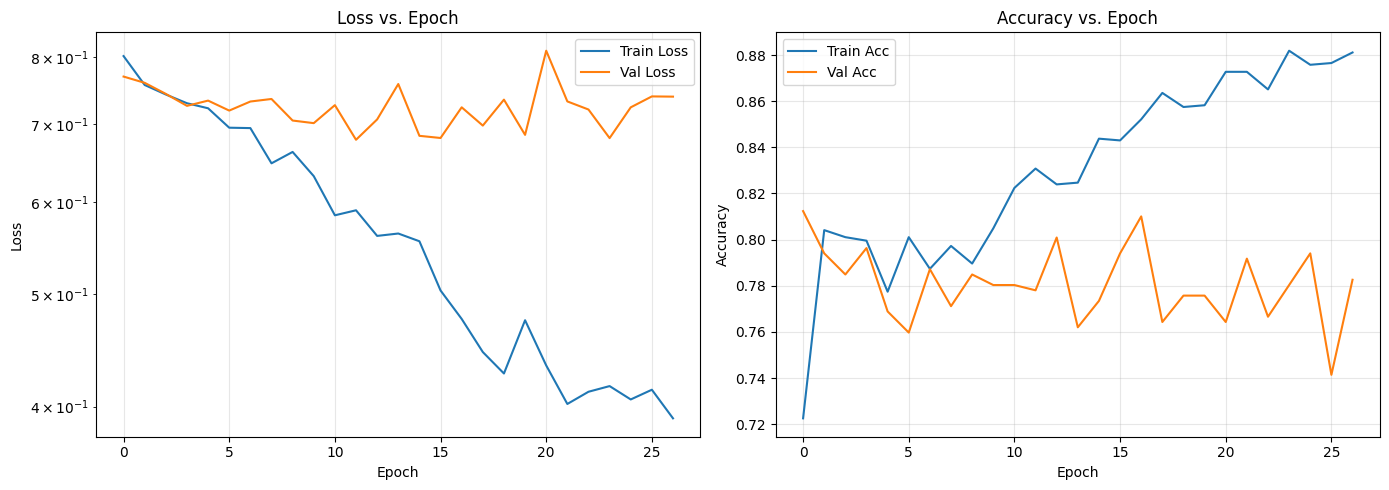

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='#1f77b4')
ax1.plot(val_losses,   label='Val Loss',   color='#ff7f0e')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_yscale('log')
ax1.set_title('Loss vs. Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Acc', color='#1f77b4')
ax2.plot(val_accs,   label='Val Acc',   color='#ff7f0e')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Evaluation on the Test Set

We collect per-star probabilities on the held-out test split, then compute:
- **ROC-AUC** (threshold-independent; the principal comparison metric across the three models)
- **PR-AUC** (`average_precision_score`) — important under class imbalance, since ROC-AUC can look optimistic when negatives vastly outnumber positives
- **Best F1** — sweep over all precision-recall thresholds and pick the one maximizing F1. The denominator is `precision + recall + 1e-8` (NOT `precision*recall + recall + 1e-8`, which was a bug in an earlier notebook that gave nonsensical F1 values).
- **Confusion matrix** at the best-F1 threshold

In [7]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix,
                             classification_report)

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for padded, mask, labels in test_loader:
        padded = padded.to(device)
        mask    = mask.to(device)
        logits  = model(padded, mask)
        probs   = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc  = average_precision_score(all_labels, all_probs)

# ── Change 2: select threshold on VAL, then report honest test metrics. ──
# (The previous version swept the PR curve on the TEST set and reported F1 at the
# test-chosen threshold -- which biases the reported F1 optimistically.)
# 1a. Collect VAL predictions.
val_probs, val_labels = [], []
with torch.no_grad():
    for padded, mask, labels in val_loader:
        padded = padded.to(device); mask = mask.to(device)
        probs = torch.sigmoid(model(padded, mask))
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

# 1b. Pick best-F1 threshold from the VAL PR curve (off-by-one guarded).
val_prec, val_rec, val_thr = precision_recall_curve(val_labels, val_probs)
val_f1 = 2 * val_prec * val_rec / (val_prec + val_rec + 1e-8)
val_best_idx = int(np.argmax(val_f1))
best_thresh = float(val_thr[val_best_idx]) if val_best_idx < len(val_thr) else 0.5

# 1c. Honest TEST metrics at the val-chosen threshold.
preds_at_thr = (all_probs >= best_thresh).astype(int)
cm_at = confusion_matrix(all_labels, preds_at_thr)
_tn, _fp, _fn, _tp = cm_at.ravel()
test_precision = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
test_recall    = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
best_f1        = 2 * test_precision * test_recall / (test_precision + test_recall) if (test_precision + test_recall) > 0 else 0.0
best_precision = test_precision
best_recall    = test_recall
# also report the VAL F1 (sanity check, not used for any comparison)
val_f1_at = float(val_f1[val_best_idx]) if val_best_idx < len(val_f1) else 0.0

print(f"ROC-AUC      : {roc_auc:.4f}   (on TEST)")
print(f"PR-AUC       : {pr_auc:.4f}    (on TEST)")
print(f"Val F1       : {val_f1_at:.4f}  (threshold = {best_thresh:.4f} chosen on VAL)")
print(f"TEST F1      : {best_f1:.4f}  (at the val-chosen threshold = {best_thresh:.4f})")
print(f"  @ test F1 : precision = {best_precision:.4f}, recall = {best_recall:.4f}")

ROC-AUC      : 0.6906   (on TEST)
PR-AUC       : 0.2980    (on TEST)
Val F1       : 0.4266  (threshold = 0.3062 chosen on VAL)
TEST F1      : 0.3939  (at the val-chosen threshold = 0.3062)
  @ test F1 : precision = 0.2873, recall = 0.6265


In [8]:
# ── Change 6: bootstrap 95% CI for ROC-AUC on the TEST set. ──
# 200 resamples with replacement, percentile method [2.5, 97.5], seed=42.
# All inter-model comparisons in this project finally become comparable: each
# ROC-AUC point estimate now carries an honest uncertainty band computed on the
# SAME shared test split (split.py).
from split import bootstrap_roc_auc
_point, _lo, _hi = bootstrap_roc_auc(all_labels, all_probs, n_resamples=200, seed=42)
print(f"[1D CNN]  ROC-AUC: {_point:.4f} (95% CI: [{_lo:.4f}, {_hi:.4f}])")


[1D CNN]  ROC-AUC: 0.6906 (95% CI: [0.6344, 0.7425])


### Confusion Matrix at Best-F1 Threshold

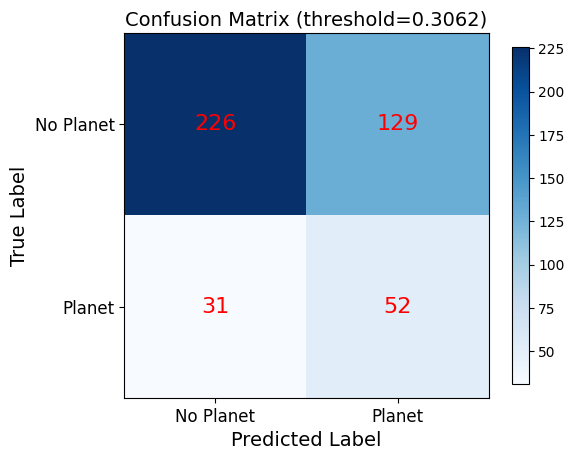

TP=52  FP=129  FN=31  TN=226
Accuracy : 0.6347
Precision: 0.2873    Recall: 0.6265


In [9]:
preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

classes = ['No Planet', 'Planet']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label',      fontsize=14)
plt.title(f'Confusion Matrix (threshold={best_thresh:.4f})', fontsize=14)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16, color='red')

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Accuracy : {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"Precision: {tp / (tp + fp):.4f}    Recall: {tp / (tp + fn):.4f}")

### Classification Report at Optimal Threshold

In [10]:
print("=" * 60)
print(f"REPORT AT DEFAULT THRESHOLD (0.5)")
print("=" * 60)
preds_05 = (all_probs >= 0.5).astype(int)
print(classification_report(all_labels, preds_05, target_names=['No Planet', 'Planet']))

print("=" * 60)
print(f"REPORT AT OPTIMAL THRESHOLD ({best_thresh:.4f})")
print("=" * 60)
preds_opt = (all_probs >= best_thresh).astype(int)
print(classification_report(all_labels, preds_opt, target_names=['No Planet', 'Planet']))

REPORT AT DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

   No Planet       0.83      0.88      0.86       355
      Planet       0.33      0.24      0.28        83

    accuracy                           0.76       438
   macro avg       0.58      0.56      0.57       438
weighted avg       0.74      0.76      0.75       438

REPORT AT OPTIMAL THRESHOLD (0.3062)
              precision    recall  f1-score   support

   No Planet       0.88      0.64      0.74       355
      Planet       0.29      0.63      0.39        83

    accuracy                           0.63       438
   macro avg       0.58      0.63      0.57       438
weighted avg       0.77      0.63      0.67       438



## 8. Comparison with Other Models

| Model | Input | ROC-AUC | PR-AUC | Best F1 |
|---|---|---|---|---|
| Random Forest (16 physical summary stats) | per-star aggregates | **0.7994** | **0.4658** | **0.5221** |
| Transformer (raw sequences, attention) | (T, 21) raw obs | 0.6793 | — | — |
| **1D CNN (raw sequences, this notebook)** | (T, 21) raw obs | *below* | *below* | *below* |

The RF baseline remains the model to beat on the small (~2000 stars) dataset: summary statistics are cheap to compute from many epochs per star and don't require any positional information. The Transformer overfits its attention map (ROC-AUC drops to 0.68). The 1D CNN sits between — its local inductive bias is much cheaper than global attention but still has to learn everything from scratch without the hand-crafted summary features the RF gets for free.

In [11]:
import pandas as pd

comparison = pd.DataFrame([
    {"Model": "RF (16 physical features)",       "Input": "per-star aggregates",  "ROC-AUC": 0.7994,  "PR-AUC": 0.4658,  "Best F1": 0.5221},
    {"Model": "Transformer (raw sequences)",     "Input": "(T, 21) raw obs",      "ROC-AUC": 0.6793,  "PR-AUC": float('nan'),  "Best F1": float('nan')},
    {"Model": "1D CNN (this notebook)",           "Input": "(T, 21) raw obs",      "ROC-AUC": roc_auc, "PR-AUC": pr_auc,         "Best F1": best_f1},
])

print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Verdict relative to baselines
print()
if roc_auc > 0.7994:
    print(f"✓ 1D CNN ({roc_auc:.4f}) BEATS the RF baseline (0.7994). Temporal structure carries signal summary statistics miss.")
elif roc_auc > 0.6793:
    print(f"• 1D CNN ({roc_auc:.4f}) beats the Transformer (0.6793) but trails the RF baseline (0.7994).")
else:
    print(f"✗ 1D CNN ({roc_auc:.4f}) trails the RF baseline (0.7994) and the Transformer baseline (0.6793).")

                      Model               Input  ROC-AUC  PR-AUC  Best F1
  RF (16 physical features) per-star aggregates   0.7994  0.4658   0.5221
Transformer (raw sequences)     (T, 21) raw obs   0.6793     NaN      NaN
     1D CNN (this notebook)     (T, 21) raw obs   0.6906  0.2980   0.3939

• 1D CNN (0.6906) beats the Transformer (0.6793) but trails the RF baseline (0.7994).
